# GAN手写数字生成器：

使用生成对抗网络(GAN)生成MNIST手写数字图像。

In [1]:
import os;
import torch;
import torch.nn as nn;
import torch.optim as optim;
from torch.utils.data import DataLoader;
from torchvision import datasets, transforms;
import matplotlib.pyplot as plt;
import numpy as np;
from tqdm import tqdm;

# 检查GPU可用性并设置设备。
if torch.cuda.is_available():
    device = torch.device("cuda");
    gpu_count = torch.cuda.device_count();
    print(f"检测到GPU数量：{gpu_count} ！");
    for i in range(gpu_count):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)} ！");
else:
    device = torch.device("cpu");
    print("警告：未检测到GPU，将使用CPU训练（速度会很慢）！");

# 设置多GPU支持。
if torch.cuda.device_count() > 1:
    print(f"使用{torch.cuda.device_count()}个GPU进行并行训练 ！");

警告：未检测到GPU，将使用CPU训练（速度会很慢）！


## 常量定义：

In [ ]:
# 训练相关超参数。
batch_size = 512;  # 批次大小，较大的batch_size可以充分利用GPU。
epochs = 25;       # 训练轮数。
lr_g = 0.0002;     # 生成器学习率。
lr_d = 0.0002;     # 判别器学习率。
latent_dim = 100;  # 噪声向量维度。
img_size = 28;     # 图像尺寸（MNIST为28x28）。
channels = 1;      # 图像通道数（MNIST为灰度图）。
sample_interval = 500;     # 每隔多少批次保存一次样本。
save_model_interval = 5;  # 每隔多少epoch保存一次模型。

# 模型保存路径。
model_save_dir = "./models";
os.makedirs(model_save_dir, exist_ok=True);

# 是否从已有模型继续训练。
continue_train = 0;                          # 设置为True则从已有模型继续训练。
continue_model_path = "./models/generator.pth";  # 继续训练时的模型路径。

# 生成样本保存路径。
sample_save_dir = "./samples";
os.makedirs(sample_save_dir, exist_ok=True);

## 数据处理：

In [3]:
# 定义数据预处理方法。
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像转换为Tensor并归一化到[0,1]。
    transforms.Normalize([0.5], [0.5])  # 标准化到[-1,1]。
]);

# 加载MNIST数据集。
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
);

# 创建数据加载器。
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,    # 使用多进程加载数据。
    pin_memory=True,  # 将数据固定在页内存中，加速GPU数据传输。
    drop_last=True    # 丢弃最后一个不完整的批次。
);

print(f"训练数据加载完成！数据集大小：{len(train_dataset)} ！");
print(f"批次数量：{len(train_loader)} ！");

100%|██████████| 9.91M/9.91M [00:06<00:00, 1.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 151kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 711kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.82MB/s]

训练数据加载完成！数据集大小：60000 ！
批次数量：117 ！


C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3528516290.py:23: UserWarning: Glyph 264

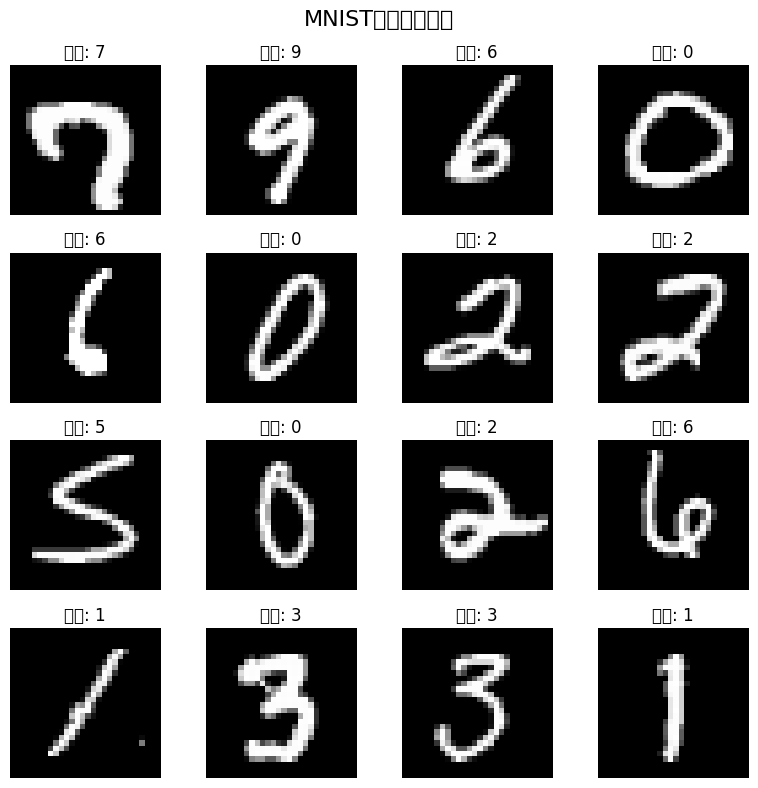

In [4]:
def preview_data(dataloader, num_images=16):
    """
    预览训练数据中的真实图像。
    参数：
        dataloader: 数据加载器。
        num_images: 要显示的图像数量。
    """
    # 获取一个批次的数据。
    real_images, labels = next(iter(dataloader));

    # 创建图像网格。
    fig, axes = plt.subplots(4, 4, figsize=(8, 8));
    fig.suptitle("MNIST真实样本预览", fontsize=16);

    for idx, ax in enumerate(axes.flat):
        if idx < num_images:
            # 反标准化图像以便显示。
            img = real_images[idx].squeeze().numpy() * 0.5 + 0.5;
            ax.imshow(img, cmap='gray');
            ax.set_title(f"标签: {labels[idx].item()}");
            ax.axis('off');

    plt.tight_layout();
    plt.show();

# 执行数据预览。
preview_data(train_loader);

## 模型搭建：

In [5]:
class Generator(nn.Module):
    """
    生成器网络。
    将随机噪声向量转换为28x28的手写数字图像。
    """
    def __init__(self, latent_dim, img_size, channels):
        super(Generator, self).__init__();
        self.latent_dim = latent_dim;
        self.img_size = img_size;
        self.channels = channels;

        # 计算初始特征图大小。
        self.init_size = img_size // 4;  # 7x7。

        # 全连接层将噪声映射到特征图。
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * self.init_size ** 2),
            nn.BatchNorm1d(128 * self.init_size ** 2),
            nn.LeakyReLU(0.2, inplace=True)
        );

        # 卷积转置层逐步上采样到目标尺寸。
        self.conv_blocks = nn.Sequential(
            # 7x7 -> 14x14。
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 14x14 -> 28x28。
            nn.ConvTranspose2d(64, channels, 4, stride=2, padding=1),
            nn.Tanh()  # 输出范围[-1,1]。
        );

    def forward(self, z):
        # 输入：噪声向量 (batch_size, latent_dim)。
        out = self.fc(z);
        out = out.view(out.size(0), 128, self.init_size, self.init_size);
        img = self.conv_blocks(out);
        return img;


class Discriminator(nn.Module):
    """
    判别器网络。
    判断输入图像是真实的还是生成的。
    """
    def __init__(self, channels, img_size):
        super(Discriminator, self).__init__();

        # 卷积层逐步下采样。
        self.conv_blocks = nn.Sequential(
            # 28x28 -> 14x14。
            nn.Conv2d(channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),

            # 14x14 -> 7x7。
            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.25),
        );

        # 计算展平后的特征维度。
        self.ds_size = img_size // 4;  # 7。

        # 全连接层输出判别结果。
        self.fc = nn.Sequential(
            nn.Linear(128 * self.ds_size ** 2, 1),
            nn.Sigmoid()  # 输出概率值[0,1]。
        );

    def forward(self, img):
        # 输入：图像 (batch_size, channels, img_size, img_size)。
        out = self.conv_blocks(img);
        out = out.view(out.size(0), -1);
        validity = self.fc(out);
        return validity;

In [6]:
# 实例化模型。
generator = Generator(latent_dim, img_size, channels);
discriminator = Discriminator(channels, img_size);

# 使用多GPU（如果可用）。
if torch.cuda.device_count() > 1:
    generator = nn.DataParallel(generator);
    discriminator = nn.DataParallel(discriminator);

# 将模型移至GPU。
generator = generator.to(device);
discriminator = discriminator.to(device);

print("生成器和判别器网络结构如下：");
print(generator);
print("——"*50);
print(discriminator);
print("——"*50);

# 定义损失函数和优化器。
adversarial_loss = nn.BCELoss();

optimizer_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999));
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999));

# 学习率调度器，用于动态调整学习率。
scheduler_G = optim.lr_scheduler.StepLR(optimizer_G, step_size=30, gamma=0.5);
scheduler_D = optim.lr_scheduler.StepLR(optimizer_D, step_size=30, gamma=0.5);

生成器和判别器网络结构如下：
Generator(
  (fc): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): BatchNorm1d(6272, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
  )
  (conv_blocks): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): Tanh()
  )
)
————————————————————————————————————————————————————————————————————————————————————————————————————
Discriminator(
  (conv_blocks): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout2d(p=0.25, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=

## 模型训练：

In [7]:
def save_sample_images(epoch, batch_idx, latent_dim, generator, device):
    """
    保存生成的样本图像。
    """
    # 生成固定噪声用于可视化。
    z = torch.randn(16, latent_dim, device=device);
    generator.eval();
    with torch.no_grad():
        gen_imgs = generator(z);
    generator.train();

    # 创建图像网格。
    fig, axes = plt.subplots(4, 4, figsize=(8, 8));
    fig.suptitle(f"Epoch {epoch}, Batch {batch_idx}", fontsize=16);

    for idx, ax in enumerate(axes.flat):
        img = gen_imgs[idx].cpu().squeeze().numpy() * 0.5 + 0.5;
        ax.imshow(img, cmap='gray');
        ax.axis('off');

    plt.tight_layout();
    plt.savefig(f"{sample_save_dir}/epoch_{epoch}_batch_{batch_idx}.png");
    plt.close();

In [8]:
def train():
    """
    主训练函数。
    """
    global generator, discriminator, optimizer_G, optimizer_D;

    start_epoch = 0;

    # 如果设置为继续训练，则加载已有模型。
    if continue_train:
        if os.path.exists(continue_model_path):
            print(f"正在从 {continue_model_path} 加载模型...");
            checkpoint = torch.load(continue_model_path, map_location=device);

            # 处理DataParallel保存的模型。
            state_dict = checkpoint;
            if 'module.' in list(state_dict.keys())[0]:
                generator.load_state_dict(state_dict);
            else:
                # 如果当前使用多GPU但保存的模型是单GPU的。
                if isinstance(generator, nn.DataParallel):
                    generator.module.load_state_dict(state_dict);
                else:
                    generator.load_state_dict(state_dict);

            # 尝试从文件名解析epoch。
            try:
                start_epoch = int(continue_model_path.split('_')[-1].split('.')[0]);
                print(f"从Epoch {start_epoch} 继续训练 ！");
            except:
                print("无法解析起始epoch，从0开始计数 ！");
                start_epoch = 0;

            print("模型加载成功 ！");
        else:
            print(f"警告：模型文件 {continue_model_path} 不存在，将从头开始训练 ！");

    print("——"*50);
    print("开始训练GAN模型...");

    # 创建固定噪声用于可视化。
    fixed_z = torch.randn(16, latent_dim, device=device);

    # 训练循环。
    for epoch in range(start_epoch, epochs):
        # 使用tqdm显示进度条。
        pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                    desc=f"Epoch {epoch+1}/{epochs}");

        for batch_idx, (real_imgs, _) in pbar:
            batch_size_current = real_imgs.size(0);

            # 真实标签和假标签。
            valid = torch.ones(batch_size_current, 1, device=device);
            fake = torch.zeros(batch_size_current, 1, device=device);

            # 将真实图像移至GPU。
            real_imgs = real_imgs.to(device, non_blocking=True);

            # ====================
            # 训练生成器
            # ====================
            optimizer_G.zero_grad();

            # 生成随机噪声。
            z = torch.randn(batch_size_current, latent_dim, device=device);

            # 生成假图像。
            gen_imgs = generator(z);

            # 计算生成器损失（希望判别器将假图像判为真）。
            g_loss = adversarial_loss(discriminator(gen_imgs), valid);

            g_loss.backward();
            optimizer_G.step();

            # ====================
            # 训练判别器
            # ====================
            optimizer_D.zero_grad();

            # 判别器对真实图像的损失。
            real_loss = adversarial_loss(discriminator(real_imgs), valid);

            # 判别器对假图像的损失（detach阻止梯度流向生成器）。
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake);

            # 总判别器损失。
            d_loss = (real_loss + fake_loss) / 2;

            d_loss.backward();
            optimizer_D.step();

            # 更新进度条信息。
            pbar.set_postfix({
                'D_loss': f'{d_loss.item():.4f}',
                'G_loss': f'{g_loss.item():.4f}'
            });

            # 定期保存样本。
            batches_done = epoch * len(train_loader) + batch_idx;
            if batches_done % sample_interval == 0:
                save_sample_images(epoch, batch_idx, latent_dim, generator, device);

        # 更新学习率。
        scheduler_G.step();
        scheduler_D.step();

        # 打印当前epoch的损失。
        print(f"Epoch [{epoch+1}/{epochs}] - D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f} ！");

        # 定期保存模型。
        if (epoch + 1) % save_model_interval == 0:
            save_path = f"{model_save_dir}/generator_epoch_{epoch+1}.pth";

            # 保存模型（处理DataParallel情况）。
            if isinstance(generator, nn.DataParallel):
                torch.save(generator.module.state_dict(), save_path);
            else:
                torch.save(generator.state_dict(), save_path);

            print(f"生成器模型已保存至 {save_path} ！");

            # 同时保存判别器。
            d_save_path = f"{model_save_dir}/discriminator_epoch_{epoch+1}.pth";
            if isinstance(discriminator, nn.DataParallel):
                torch.save(discriminator.module.state_dict(), d_save_path);
            else:
                torch.save(discriminator.state_dict(), d_save_path);

            print(f"判别器模型已保存至 {d_save_path} ！");

    print("✅训练完成！");
    print("——"*50);

    # 保存最终模型。
    final_path = f"{model_save_dir}/generator_final.pth";
    if isinstance(generator, nn.DataParallel):
        torch.save(generator.module.state_dict(), final_path);
    else:
        torch.save(generator.state_dict(), final_path);
    print(f"最终模型已保存至 {final_path} ！");

In [9]:
# 执行训练。
train();

————————————————————————————————————————————————————————————————————————————————————————————————————
开始训练GAN模型...


Epoch 1/25: 100%|██████████| 117/117 [01:11<00:00,  1.65it/s, D_loss=0.0121, G_loss=4.8469]


Epoch [1/25] - D_loss: 0.0121, G_loss: 4.8469 ！


Epoch 2/25: 100%|██████████| 117/117 [01:18<00:00,  1.50it/s, D_loss=0.4597, G_loss=1.1401]


Epoch [2/25] - D_loss: 0.4597, G_loss: 1.1401 ！


...

Epoch [23/25] - D_loss: 0.4671, G_loss: 1.3085 ！


Epoch 24/25: 100%|██████████| 117/117 [01:17<00:00,  1.51it/s, D_loss=0.4818, G_loss=1.0135]


Epoch [24/25] - D_loss: 0.4818, G_loss: 1.0135 ！


Epoch 25/25: 100%|██████████| 117/117 [01:09<00:00,  1.68it/s, D_loss=0.4136, G_loss=1.5353]

Epoch [25/25] - D_loss: 0.4136, G_loss: 1.5353 ！
✅训练完成！
————————————————————————————————————————————————————————————————————————————————————————————————————
最终模型已保存至 ./models/generator_final.pth ！


In [10]:
def test_generator(model_path=None, num_samples=4):
    """
    测试生成器效果。
    参数：
        model_path: 模型文件路径，为None则使用当前训练好的模型。
        num_samples: 生成的样本数量。
    """
    print("开始测试生成器效果...");
    print("——"*50);

    # 加载模型（如果需要）。
    if model_path is not None and os.path.exists(model_path):
        test_generator_model = Generator(latent_dim, img_size, channels).to(device);
        checkpoint = torch.load(model_path, map_location=device);

        # 处理可能的DataParallel前缀。
        state_dict = {};
        for k, v in checkpoint.items():
            name = k.replace('module.', '') if k.startswith('module.') else k;
            state_dict[name] = v;

        test_generator_model.load_state_dict(state_dict);
        test_generator_model.eval();
        print(f"已从 {model_path} 加载模型进行测试 ！");
    else:
        test_generator_model = generator;
        test_generator_model.eval();
        if model_path is not None:
            print(f"模型文件 {model_path} 不存在，使用当前训练好的模型 ！");

    # 生成随机噪声。
    z = torch.randn(num_samples, latent_dim, device=device);

    # 生成图像。
    with torch.no_grad():
        gen_imgs = test_generator_model(z);

    # 创建图像网格。
    grid_size = int(np.sqrt(num_samples));
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12));
    fig.suptitle("GAN生成手写数字样本", fontsize=20);

    for idx, ax in enumerate(axes.flat):
        if idx < num_samples:
            # 反标准化图像。
            img = gen_imgs[idx].cpu().squeeze().numpy() * 0.5 + 0.5;
            ax.imshow(img, cmap='gray');
            ax.axis('off');

    plt.tight_layout();
    # plt.savefig(f"{sample_save_dir}/generated_samples_test.png", dpi=150);
    plt.show();
    # print(f"生成样本已保存至 {sample_save_dir}/generated_samples_test.png ！");

    # # 生成一个大的拼接图用于展示。
    # fig, axes = plt.subplots(8, 8, figsize=(16, 16));
    # fig.suptitle("GAN生成效果展示（8x8网格）", fontsize=24);

    # for i in range(8):
    #     for j in range(8):
    #         idx = i * 8 + j;
    #         img = gen_imgs[idx].cpu().squeeze().numpy() * 0.5 + 0.5;
    #         axes[i, j].imshow(img, cmap='gray');
    #         axes[i, j].axis('off');

    # plt.tight_layout();
    # # plt.savefig(f"{sample_save_dir}/generated_grid_8x8.png", dpi=200);
    # plt.show();
    # # print(f"8x8网格样本已保存至 {sample_save_dir}/generated_grid_8x8.png ！");

    # 生成插值图像展示生成器的平滑性。
    print("正在生成插值样本...");
    num_interpolation = 10;
    z_start = torch.randn(1, latent_dim, device=device);
    z_end = torch.randn(1, latent_dim, device=device);

    # 线性插值。
    alphas = torch.linspace(0, 1, num_interpolation, device=device).view(-1, 1);
    z_interpolation = alphas * z_end + (1 - alphas) * z_start;

    with torch.no_grad():
        interp_imgs = test_generator_model(z_interpolation);

    fig, axes = plt.subplots(1, num_interpolation, figsize=(20, 2));
    fig.suptitle("潜在空间插值效果", fontsize=16);

    for idx, ax in enumerate(axes):
        img = interp_imgs[idx].cpu().squeeze().numpy() * 0.5 + 0.5;
        ax.imshow(img, cmap='gray');
        ax.axis('off');
        ax.set_title(f"α={alphas[idx].item():.1f}");

    plt.tight_layout();
    # plt.savefig(f"{sample_save_dir}/interpolation_samples.png", dpi=150);
    plt.show();
    # print(f"插值样本已保存至 {sample_save_dir}/interpolation_samples.png ！");

    print("——"*50);

开始测试生成器效果...
————————————————————————————————————————————————————————————————————————————————————————————————————


C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:50: UserWarning: Glyph 233

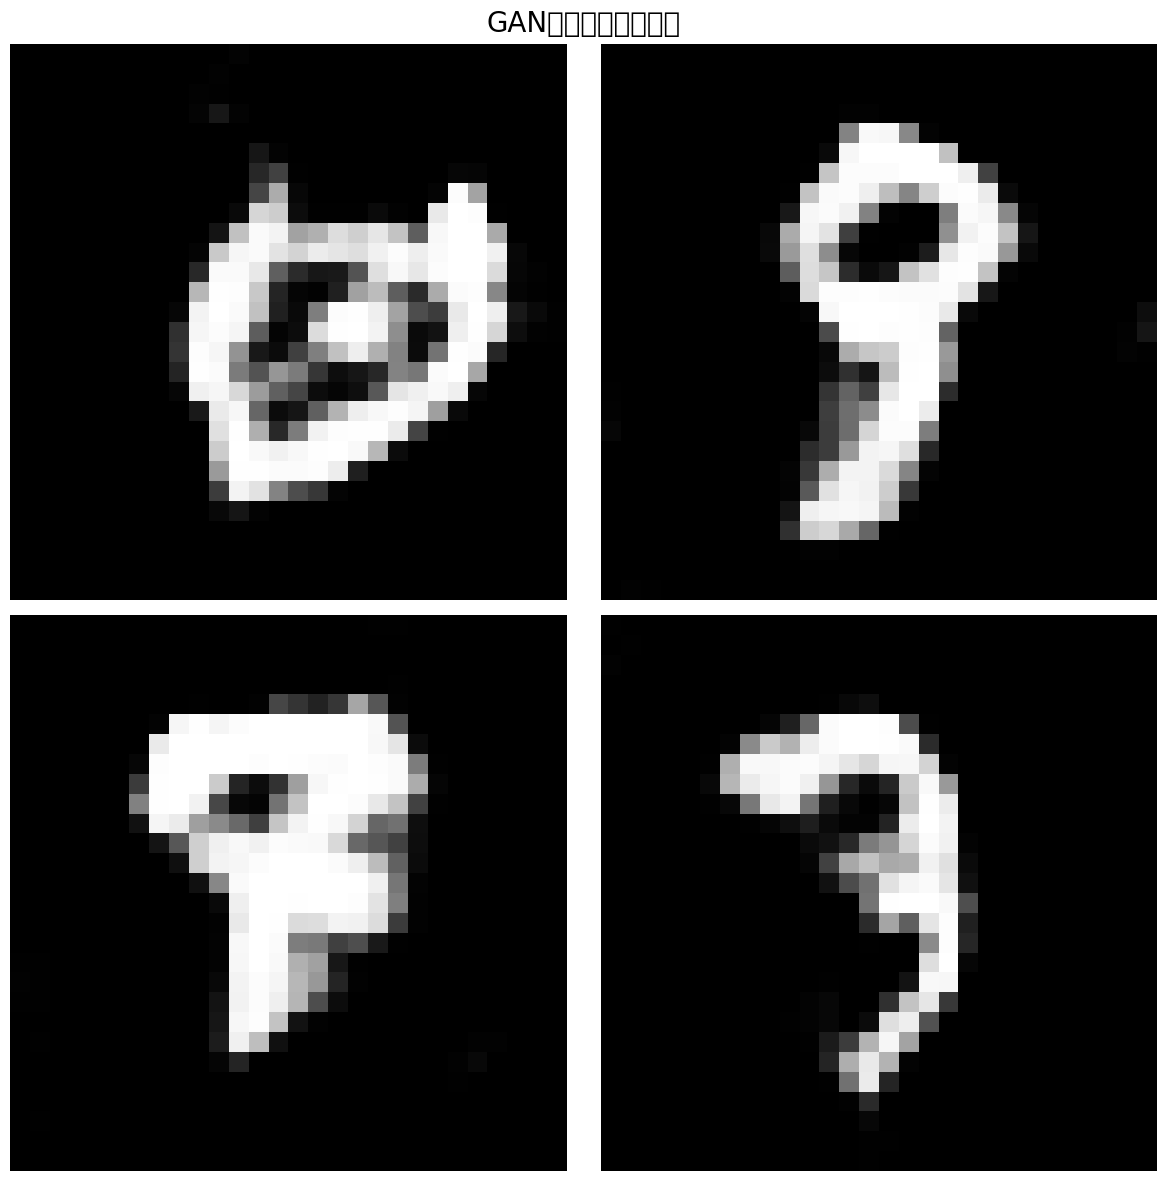

正在生成插值样本...


C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 28508 (\N{CJK UNIFIED IDEOGRAPH-6F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 25554 (\N{CJK UNIFIED IDEOGRAPH-63D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout();
C:\Users\anjuxi\AppData\Local\Temp\ipykernel_3580\3403366855.py:93: UserWarning: Glyph 205

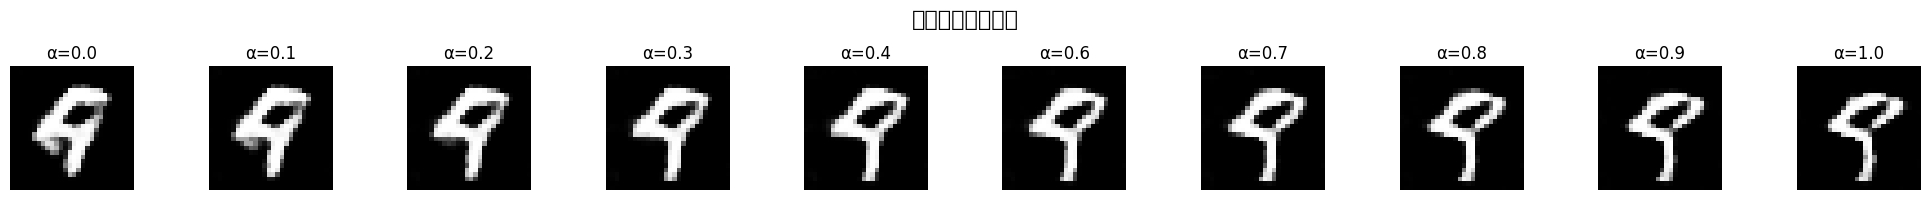

————————————————————————————————————————————————————————————————————————————————————————————————————


In [11]:
test_generator();